# Assignment 4

Deadline: 13.05.2026, 12:00 CET

**Submitted by:** Luca Francesco Besomi, 20-206-769, lucafrancesco.besomi@uzh.ch; Francesco Carlo Filippo Orsingher, 21-986-971, francescocarlofilippo.orsingher@uzh.ch; Devin Liam Rohr, 16-454-753, devinliam.rohr@uzh.ch; Tamas Terner, 19-755-495, tamas.terner@uzh.ch

In [17]:
# Standard library imports
import os
import sys

# Third party imports
import numpy as np
import pandas as pd
import statsmodels.api as sm    # for regression analysis in 1.c) (or any other regression library you prefer)

# Add the project root directory to Python path
project_root = os.path.dirname(os.path.abspath(''))
src_path = os.path.join(project_root, 'src')
sys.path.append(project_root)
sys.path.append(src_path)

# Local modules imports
from helper_functions import (
    load_pickle,
    load_data_spi,
    align_market_data_with_jkp_data,
)
from estimation.covariance import Covariance
from optimization.optimization import PercentilePortfolio
from backtesting.backtest_item_builder.bib_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_gaps,
    bibfn_selection_min_volume,
    bibfn_selection_jkp_data_scores,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_scores,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest

## Constants

In [18]:
PATH_TO_DATA = os.path.join(os.getcwd(), '..', 'data') + os.sep      # <change this to your path to data>
SAVE_PATH = os.path.join(os.getcwd(), '..', 'results') + os.sep     # <change this to your path where you want to store the backtest>

## Load data and initialize BacktestData class
- market data (from parquet file)
- jkp data (from parquet file)
- swiss performance index, SPI (from csv file)

In [19]:
# Load market and jkp data from parquet files
market_data = pd.read_parquet(path = f'{PATH_TO_DATA}market_data.parquet')
jkp_data = pd.read_parquet(path = f'{PATH_TO_DATA}jkp_data.parquet')
spi = load_data_spi(path='../data/')

# Align market data with jkp data
market_data_ffill, jkp_data = align_market_data_with_jkp_data(market_data=market_data, jkp_data=jkp_data)

# Instantiate the BacktestData class
# and set the market, jkp, and benchmark data as attributes
data = BacktestData()
data.market_data = market_data_ffill  # notice that we use the forward filled market data here
data.jkp_data = jkp_data
data.bm_series = spi

## Define a grid or rebalancing dates

In [20]:
n_month = 3 # We want to rebalance every n_month months
jkp_data_dates = (
    jkp_data
    .index.get_level_values('date')
    .unique().sort_values()
)
rebdates = (
    jkp_data_dates[
        jkp_data_dates > market_data.index.get_level_values('date').min()
    ][::n_month]
    .strftime('%Y-%m-%d').tolist()
)
rebdates = [date for date in rebdates if date > '2002-01-01']
rebdates

['2002-01-31',
 '2002-04-30',
 '2002-07-31',
 '2002-10-31',
 '2003-01-31',
 '2003-04-30',
 '2003-07-31',
 '2003-10-31',
 '2004-01-31',
 '2004-04-30',
 '2004-07-31',
 '2004-10-31',
 '2005-01-31',
 '2005-04-30',
 '2005-07-31',
 '2005-10-31',
 '2006-01-31',
 '2006-04-30',
 '2006-07-31',
 '2006-10-31',
 '2007-01-31',
 '2007-04-30',
 '2007-07-31',
 '2007-10-31',
 '2008-01-31',
 '2008-04-30',
 '2008-07-31',
 '2008-10-31',
 '2009-01-31',
 '2009-04-30',
 '2009-07-31',
 '2009-10-31',
 '2010-01-31',
 '2010-04-30',
 '2010-07-31',
 '2010-10-31',
 '2011-01-31',
 '2011-04-30',
 '2011-07-31',
 '2011-10-31',
 '2012-01-31',
 '2012-04-30',
 '2012-07-31',
 '2012-10-31',
 '2013-01-31',
 '2013-04-30',
 '2013-07-31',
 '2013-10-31',
 '2014-01-31',
 '2014-04-30',
 '2014-07-31',
 '2014-10-31',
 '2015-01-31',
 '2015-04-30',
 '2015-07-31',
 '2015-10-31',
 '2016-01-31',
 '2016-04-30',
 '2016-07-31',
 '2016-10-31',
 '2017-01-31',
 '2017-04-30',
 '2017-07-31',
 '2017-10-31',
 '2018-01-31',
 '2018-04-30',
 '2018-07-

## 1. a) Define the key data fields that characterize a factor theme

- Beside the pre-defined fields, choose three factor themes from table 9 of the Global Factor Data Documentation (See https://jkpfactors-data.s3.amazonaws.com/documents/Documentation.pdf, Section 10.) and add the individual fields.

**(2 points)**

In [25]:
JKP_FIELDS_QUALITY = [
    'at_turnover',
    'cop_at',
    'cop_atl1',
    'dgp_dsale',
    'gp_at',
    'gp_atl1',
    'mispricing_perf',
    'ni_inc8q',
    'niq_at',
    'op_at',
    'op_atl1',
    'opex_at',
    'qmj_prof',
    'qmj_growth',
    'qmj_safety',
    'sale_bev',
]

JKP_FIELDS_VALUE = [
    'at_me',
    'be_me',
    'bev_mev',
    'debt_me',
    'div12m_me',
    'ebitda_mev',
    'eq_dur',
    'eqnetis_at',
    'eqnpo_12m',
    'eqnpo_me',
    'fcf_me',
    'ival_me',
    'netis_at',
    'ni_me',
    'ocf_me',
    'sale_me',
]

JKP_FIELDS_MOMENTUM = [
    'prc_highprc_252d',
    'resff3_6_1',
    'resff3_12_1',
    'ret_3_1',
    'ret_6_1',
    'ret_9_1',
    'ret_12_1',
    'seas_1_1na',
]

# Profitability — captures the earnings/profitability anomaly (JKP Table 9).
# Firms with higher profitability tend to outperform. Distinct from quality
# (which combines profitability, growth and safety) by focusing purely
# on earnings-based return measures.
JKP_FIELDS_PROFITABILITY = [
    'ebit_bev',
    'ebit_sale',
    'f_score',
    'ni_be',
    'niq_at',
    'niq_be',
    'o_score',
    'ocf_at',
    'ope_be',
    'ope_bel1',
    'turnover_var_126d',
    'dolvol_var_126d',
]

# Investment — captures the asset growth / capital expenditure anomaly (JKP Table 9).
# Firms that invest aggressively tend to underperform; this theme shorts
# high-investment firms and complements the quality theme well.
JKP_FIELDS_INVESTMENT = [
    'aliq_at',
    'at_gr1',
    'be_gr1a',
    'capx_gr1',
    'capx_gr2',
    'capx_gr3',
    'coa_gr1a',
    'col_gr1a',
    'emp_gr1',
    'inv_gr1',
    'inv_gr1a',
    'lnoa_gr1a',
    'mispricing_mgmt',
    'ncoa_gr1a',
    'nncoa_gr1a',
    'noa_gr1a',
    'ppeinv_gr1a',
    'ret_60_12',
    'sale_gr1',
    'sale_gr3',
    'saleq_gr1',
    'seas_2_5na',
]

# Accruals — captures the accruals anomaly (JKP Table 9).
# High accruals relative to assets or earnings signal lower earnings quality
# and predict lower future returns. Distinct from momentum and value signals.
JKP_FIELDS_ACCRUALS = [
    'cowc_gr1a',
    'oaccruals_at',
    'oaccruals_ni',
    'taccruals_at',
    'taccruals_ni',
]

JKP_FIELDS = {
    'quality':       JKP_FIELDS_QUALITY,
    'value':         JKP_FIELDS_VALUE,
    'momentum':      JKP_FIELDS_MOMENTUM,
    'profitability': JKP_FIELDS_PROFITABILITY,
    'investment':    JKP_FIELDS_INVESTMENT,
    'accruals':      JKP_FIELDS_ACCRUALS,
}

## 1. b) Factor series for each factor theme.

- For each factor theme, run a backtest for the top‑quintile portfolio and a second backtest for the bottom‑quintile portfolio.

- Simulate the return streams for both backtests and define the factor series as a long-short portfolio going long the top quintile portfolio and going short the bottom quintile portfolio.

- Plot the cumulative returns of the top quintile portfolio, the bottom quintile portfolio, the long-short factor portfolio, and the benchmark series.

**(8 points)**

In [22]:
# Validate that all required fields are present in the JKP dataset.
# Raises immediately so a missing field is never silently ignored.
for theme_name, fields in JKP_FIELDS.items():
    missing = [f for f in fields if f not in data.jkp_data.columns]
    if missing:
        raise ValueError(
            f"Theme '{theme_name}' is missing fields: {missing}. "
            "Check your JKP data version or field names."
        )
    else:
        print(f"{theme_name}: all fields OK")

quality: all fields OK
value: all fields OK
momentum: all fields OK
profitability: all fields OK
investment: all fields OK
accruals: all fields OK


Running backtests for theme: 'quality' ...


C:\Users\Devin\AppData\Local\Temp\ipykernel_18808\1807021297.py:97: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  plot_df = pd.concat({


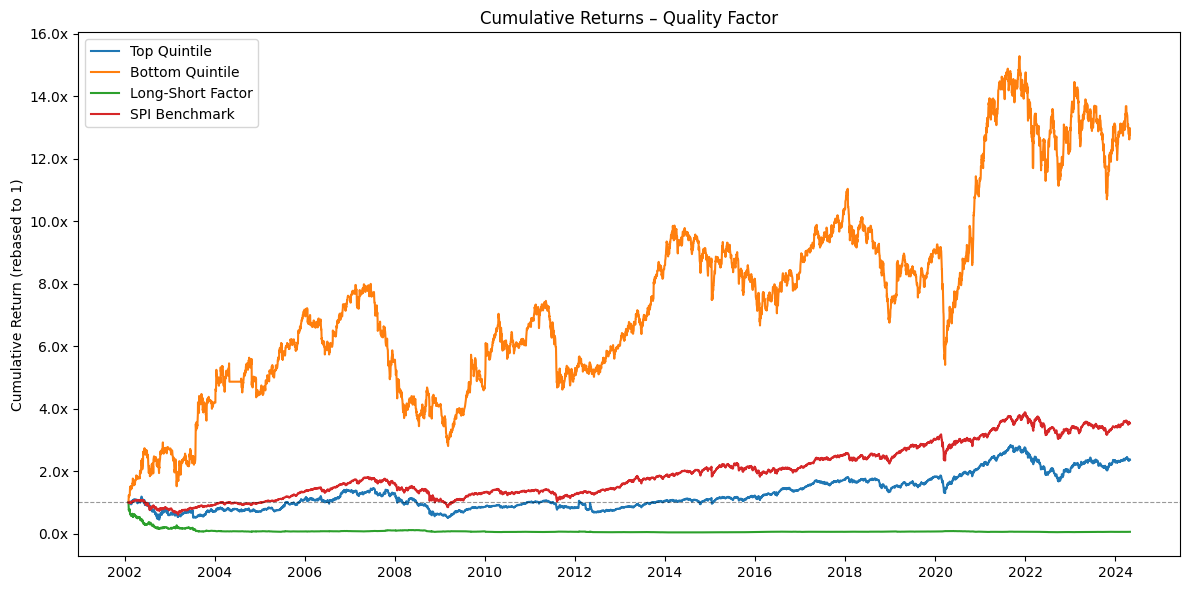

Running backtests for theme: 'value' ...


C:\Users\Devin\AppData\Local\Temp\ipykernel_18808\1807021297.py:97: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  plot_df = pd.concat({


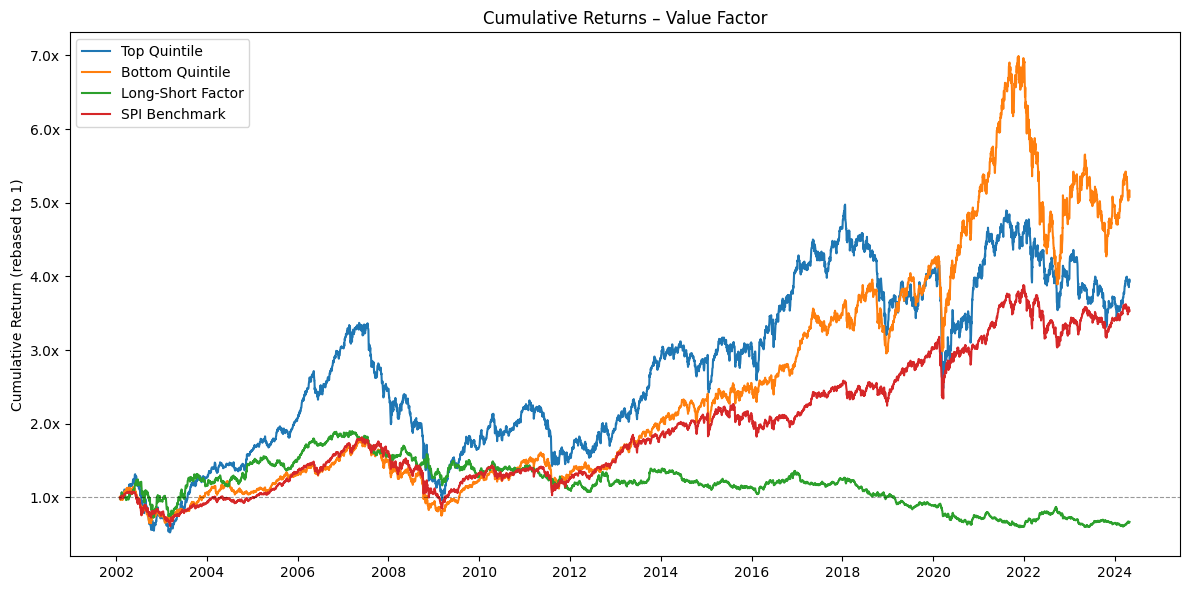

Running backtests for theme: 'momentum' ...


C:\Users\Devin\AppData\Local\Temp\ipykernel_18808\1807021297.py:97: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  plot_df = pd.concat({


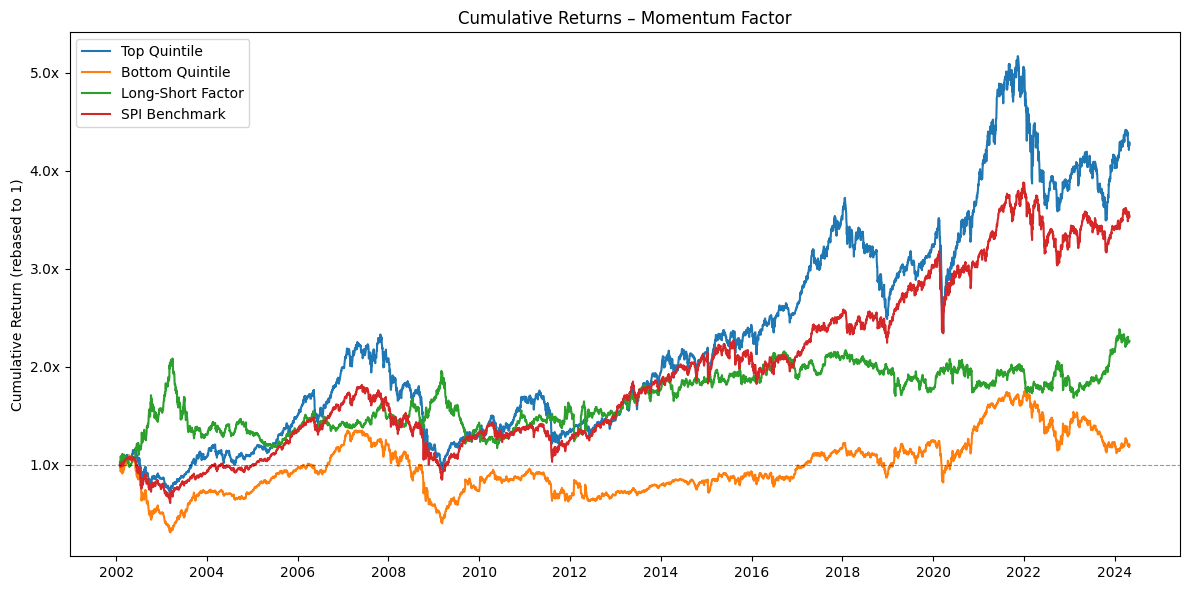

Running backtests for theme: 'profitability' ...


C:\Users\Devin\AppData\Local\Temp\ipykernel_18808\1807021297.py:97: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  plot_df = pd.concat({


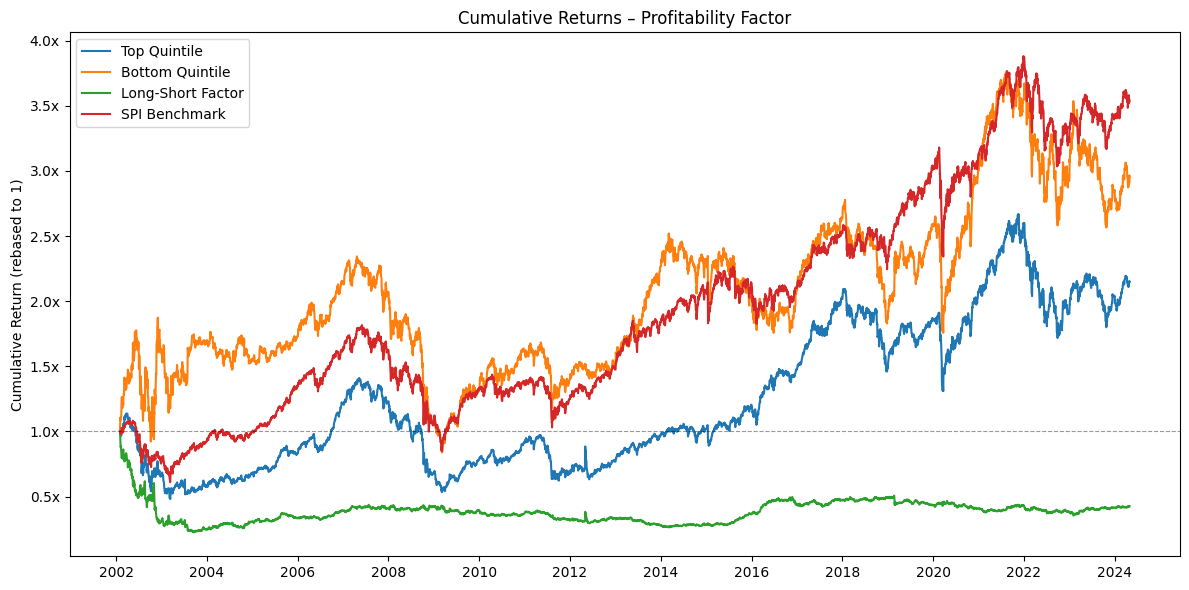

Running backtests for theme: 'investment' ...


C:\Users\Devin\AppData\Local\Temp\ipykernel_18808\1807021297.py:97: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  plot_df = pd.concat({


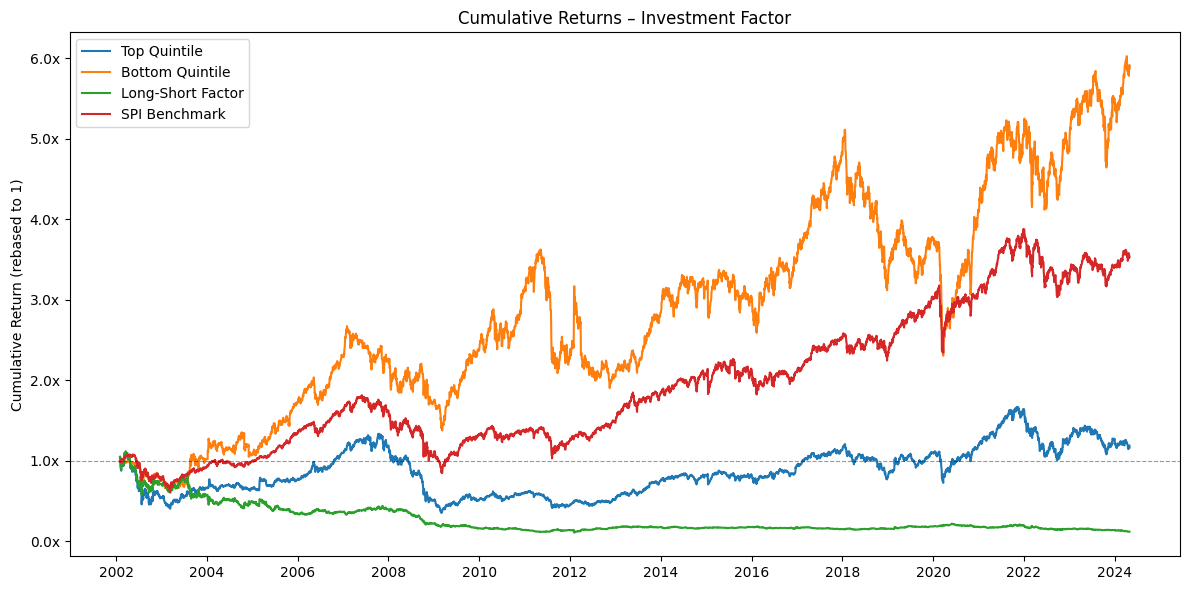

Running backtests for theme: 'accruals' ...


C:\Users\Devin\AppData\Local\Temp\ipykernel_18808\1807021297.py:97: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  plot_df = pd.concat({


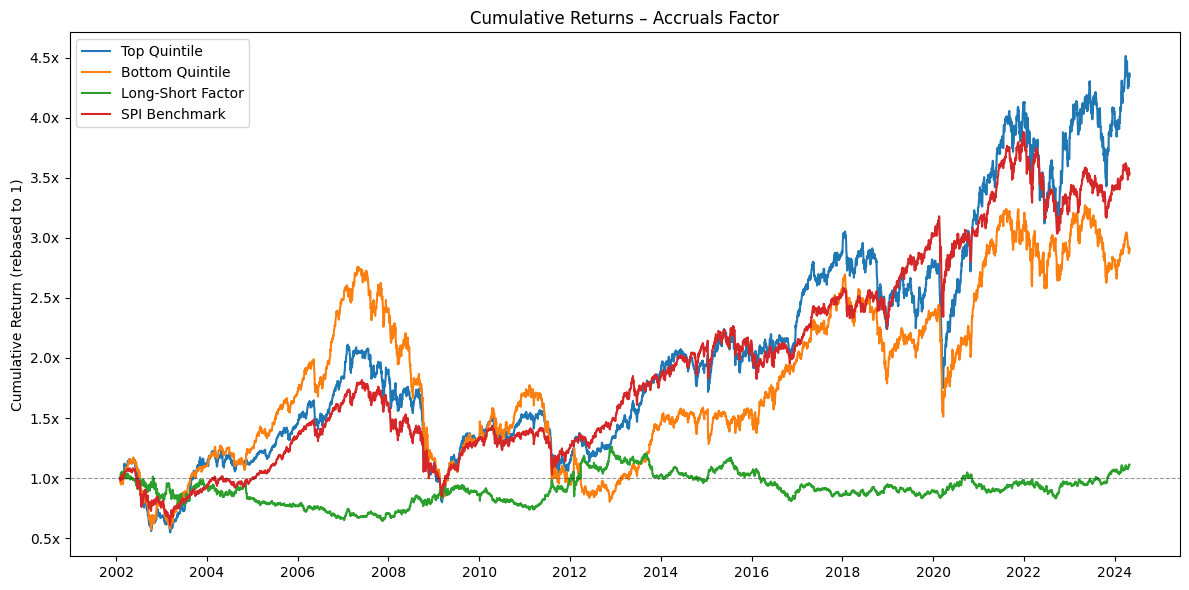

In [27]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# weekdays_only=False: JKP data can include non-trading-day entries;
# keeping all calendar days avoids inadvertently dropping valid signal dates.
return_series = data.get_return_series(weekdays_only=False)
factor_simulations = {}

for theme_name, fields in JKP_FIELDS.items():
    print(f"Running backtests for theme: '{theme_name}' ...")

    score_weights = {f: 1 / len(fields) for f in fields}

    selection_ibs = {
        'gaps': SelectionItemBuilder(
            bibfn=bibfn_selection_gaps,
            width=365 * 3,
            n_days=10,
        ),
        'min_volume': SelectionItemBuilder(
            bibfn=bibfn_selection_min_volume,
            width=365 * 3,
            min_volume=500_000,
            agg_fn=np.median,
        ),
        'jkp_data_scores': SelectionItemBuilder(
            bibfn=bibfn_selection_jkp_data_scores,
            fields=fields,
        ),
    }

    optimization_ibs = {
        'scores': OptimizationItemBuilder(
            bibfn=bibfn_scores,
            fields=fields,
        ),
    }

    # Two independent BacktestService instances — one per quintile.
    # Avoids the risk of stale cached state from the top-quintile run
    # leaking into the bottom-quintile run if BacktestService mutates
    # internal state during Backtest.run().
    bs_top = BacktestService(
        data=data,
        selection_item_builders=selection_ibs,
        optimization_item_builders=optimization_ibs,
        rebdates=rebdates,
    )
    bs_top.settings['quiet'] = True
    bs_top.optimization = PercentilePortfolio(
        score_weights=score_weights,
        percentile=80,
        sign='>=',
    )

    bs_bottom = BacktestService(
        data=data,
        selection_item_builders=selection_ibs,
        optimization_item_builders=optimization_ibs,
        rebdates=rebdates,
    )
    bs_bottom.settings['quiet'] = True
    bs_bottom.optimization = PercentilePortfolio(
        score_weights=score_weights,
        percentile=20,
        sign='<=',
    )

    bt_top = Backtest()
    try:
        bt_top.run(bs=bs_top)
        # fc=0, vc=0: no transaction costs — appropriate for a pure factor signal study
        # where the goal is to isolate signal quality, not implementation realism.
        sim_top = bt_top.strategy.simulate(return_series=return_series, fc=0, vc=0)
    except (RuntimeError, IndexError) as e:
        print(f"  Warning: top quintile for '{theme_name}' had empty periods, skipping: {e}")
        sim_top = pd.Series(0.0, index=return_series.index)

    bt_bottom = Backtest()
    try:
        bt_bottom.run(bs=bs_bottom)
        sim_bottom = bt_bottom.strategy.simulate(return_series=return_series, fc=0, vc=0)
    except (RuntimeError, IndexError) as e:
        print(f"  Warning: bottom quintile for '{theme_name}' had empty periods, skipping: {e}")
        sim_bottom = pd.Series(0.0, index=return_series.index)

    # Long-short factor series: long top quintile, short bottom quintile
    sim_factor = sim_top - sim_bottom

    factor_simulations[theme_name] = {
        'top':    sim_top,
        'bottom': sim_bottom,
        'factor': sim_factor,
    }

    # Plot cumulative returns
    plot_df = pd.concat({
        'Top Quintile':      sim_top,
        'Bottom Quintile':   sim_bottom,
        'Long-Short Factor': sim_factor,
        'SPI Benchmark':     data.bm_series,
    }, axis=1).dropna()

    cum_ret = (1 + plot_df).cumprod()

    fig, ax = plt.subplots(figsize=(12, 6))
    cum_ret.plot(ax=ax)
    ax.set_title(f'Cumulative Returns – {theme_name.replace("_", " ").title()} Factor')
    ax.set_ylabel('Cumulative Return (rebased to 1)')
    ax.set_xlabel('')
    ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--', alpha=0.4, label='_nolegend_')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}x'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, ha='center')
    plt.tight_layout()
    plt.show()

## 1. c) Factor analysis

- First, compute a factor-mix return series by averaging the returns of the top-quintile portfolio simulations that you have computed above. 

- Second, run an ordinary least squares regression of y on X, where y is your factor-mix series and X contains i) a constant, ii) the SPI return series, and iii) the factor return series computed in 1.b).

- Use monthly returns.

- Print a summary table of the regression output

**(5 points)**

In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Factor-mix: equal-weighted average of all top-quintile return streams
top_df = pd.concat(
    {name: d['top'] for name, d in factor_simulations.items()},
    axis=1,
).dropna()
factor_mix = top_df.mean(axis=1)

# Resample daily returns to monthly using geometric compounding
def to_monthly(series):
    return ((1 + series).resample('ME').prod() - 1).dropna()

y                 = to_monthly(factor_mix)
spi_monthly       = to_monthly(data.bm_series)
factor_ls_monthly = {name: to_monthly(d['factor']) for name, d in factor_simulations.items()}

# Join all series into one DataFrame and drop any month with a missing value.
reg_df = pd.concat(
    {'y': y, 'spi': spi_monthly, **factor_ls_monthly},
    axis=1,
).dropna()

y_reg = reg_df['y']
X_reg = sm.add_constant(reg_df.drop(columns='y'))

# OLS regression: factor_mix ~ const + SPI + L/S factor series (one per theme)
model = sm.OLS(y_reg, X_reg).fit()
print(model.summary())

# --- Multicollinearity check ---
# With 6 factor series + SPI as regressors, some correlation is expected
# (e.g. quality and low-risk overlap). VIF > 10 signals unreliable coefficients.
vif_df = pd.DataFrame({
    'feature': X_reg.columns,
    'VIF':     [variance_inflation_factor(X_reg.values, i)
                for i in range(X_reg.shape[1])],
})
print("\nVariance Inflation Factors:")
print(vif_df.to_string(index=False))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.767
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     121.9
Date:                Tue, 12 May 2026   Prob (F-statistic):           3.28e-78
Time:                        22:17:14   Log-Likelihood:                 595.34
No. Observations:                 267   AIC:                            -1175.
Df Residuals:                     259   BIC:                            -1146.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0001      0.002      0.090

C:\Users\Devin\AppData\Local\Temp\ipykernel_18808\1662118082.py:19: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  reg_df = pd.concat(
